In [1]:
import os
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

### Inputs

In [2]:
# Results directory
results_directory = './v10_1_results/'
output_directory= './timeseries_plots/'

In [3]:
def extract_ensemble(results_directory: str, subbasin_id: str, variable= 'cout', exclude_members=True):
    """
    Extracts ensemble data from files, filters by subbasin ID, and optionally excludes members not found in the offical ensemble.

    Parameters:
        results_directory (str): Path to the directory containing result files.
        subbasin_id (str): Identifier for filtering files belonging to a specific subbasin.
        exclude_members (bool): If True, excludes specified model members.

    Returns:
        xarray.DataArray: Combined ensemble data as an xarray DataArray.
    """
    # List of model names to exclude (not in official ensemble)
    exclude_models = [
        'CanESM5', 'CNRM-CM6-1', 'EC-Earth3', 'IPSL-CM6A-LR',
        'UKESM1-0-LL', 'NorESM2-MM', 'EC-Earth3-CC', 'NESM3',
        'EC-Earth3-Veg', 'INM-CM4-8', 'TaiESM1'
    ]
    
    # Check for files of required subbasin_id
    file_list = [os.path.join(results_directory, filename) for filename in os.listdir(results_directory)
                 if subbasin_id in filename]  # Only filter by subbasin_id
    
    # Create an empty list to store xarray DataArrays
    data_arrays: List[xr.DataArray] = []
    member_names = []  # To store the 'name' of each DataArray for concatenation

    # Loop through each file
    for file_path in file_list:
        # Extract the filename without extension to use as the member name
        member_name = os.path.splitext(os.path.basename(file_path))[0]

        # Conditionally exclude models if exclude_members is True
        if exclude_members and (any(excluded in member_name for excluded in exclude_models) or 'ssp585' in member_name):
            continue
        
        # Read the file into a pandas DataFrame
        df = pd.read_csv(file_path, sep='\t', index_col=0, low_memory=False)

        # Drop the first row to remove units
        df = df.iloc[1:]

        df= df[[variable]]
        
    #    print(df)

        # Convert the DataFrame to an xarray DataArray
        data_array = xr.DataArray(df.values, dims=('DATE', 'variable'),
                                  coords={'DATE': df.index, 'variable': df.columns})
        
        # Assign the filename as the name of the DataArray
        data_array.name = member_name
        
        # Append the DataArray to the list
        data_arrays.append(data_array)
        member_names.append(member_name)  # Keep track of the member name

    # Check if any valid data arrays exist
    if not data_arrays:
        return xr.DataArray()  # Return an empty DataArray if no valid members are left
    
    # Concatenate the list of DataArrays along dimension 'member'
    ds = xr.concat(data_arrays, dim='member')
    
    # Add the member names as a coordinate
    ds.coords['member'] = ('member', member_names)

    # Convert 'DATE' coordinate to datetime, specifying the format and handling errors
    ds['DATE'] = pd.to_datetime(ds['DATE'], format='%Y-%m-%d', errors='coerce')

    # Select the specified variable from the dataset
    var_data = ds.sel(variable='cout')

    # Convert data to numeric
    var_data = var_data.astype(float)
    
    return var_data

In [4]:
def plot_streamflow_time_series(data_array, location, output_directory, date_range=None, log_y=False):
    """
    Plots the ensemble median with a 95% confidence interval shading.
    
    Parameters:
    - data_array (xarray.DataArray): The input data array with dimensions ('DATE', 'member').
    - date_range (tuple, optional): A tuple (start_date, end_date) to filter the data.
    - log_y (bool, optional): If True, sets the y-axis to a logarithmic scale.
    """
    # Convert data to numeric if necessary
    data_array = data_array.astype(float)

    # Filter by date range if provided
    if date_range:
        start_date, end_date = date_range
        data_array = data_array.sel(DATE=slice(start_date, end_date))

    # Compute median and percentiles
    median = data_array.median(dim="member")
    lower_bound = data_array.quantile(0.025, dim="member")
    upper_bound = data_array.quantile(0.975, dim="member")

    # Create plot
    plt.figure(figsize=(18, 4))
    
    # Plot shaded confidence interval
    plt.fill_between(
        data_array['DATE'].values,
        lower_bound,
        upper_bound,
        color='blue',
        alpha=0.2,
        label="95% Confidence Interval"
    )

    # Plot median line with a thinner linewidth
    plt.plot(data_array['DATE'], median, color='blue', linestyle='-', linewidth=1, label="Ensemble Median")

    # Set logarithmic y-axis if requested
    if log_y:
        plt.yscale("log")

    # Customize plot
    plt.xlabel("Time")
    plt.ylabel("Streamflow (cms)")
    plt.title(f"Streamflow Timeseries at {location}")
    plt.legend()
    plt.grid(True)

        # Save plot if output directory is provided
    if output_directory:
        os.makedirs(output_directory, exist_ok=True)
        filename = f"{location}_streamflow_timeseries.png"
        filepath = os.path.join(output_directory, filename)
        plt.savefig(filepath, dpi=300, bbox_inches="tight")
        print(f"Plot saved to {filepath}")

    
    # Show plot
    plt.show()

### Streamflow

In [5]:
# Extract the streamflow ensembles
milk_official_ensemble= extract_ensemble(results_directory, '58308', 'cout', True)
stm_official_ensemble= extract_ensemble(results_directory, '58208', 'cout', True)

Plot saved to ./timeseries_plots/MREIB_streamflow_timeseries.png


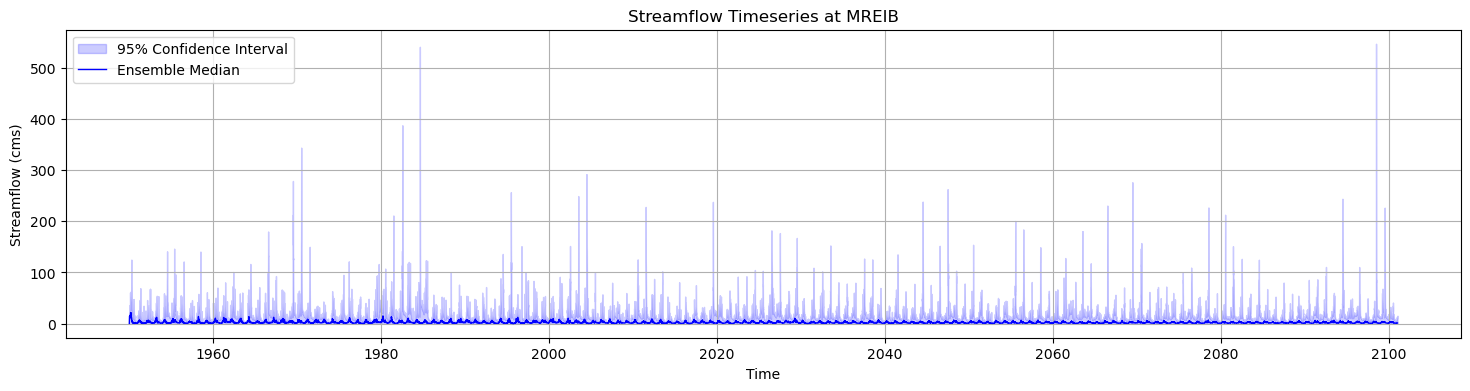

In [6]:
# Plot Milk River streamflow timeseries
plot_streamflow_time_series(milk_official_ensemble, 'MREIB', output_directory, date_range=("1950-01-01", "2100-12-31"), log_y=False)

Plot saved to ./timeseries_plots/SMRIB_streamflow_timeseries.png


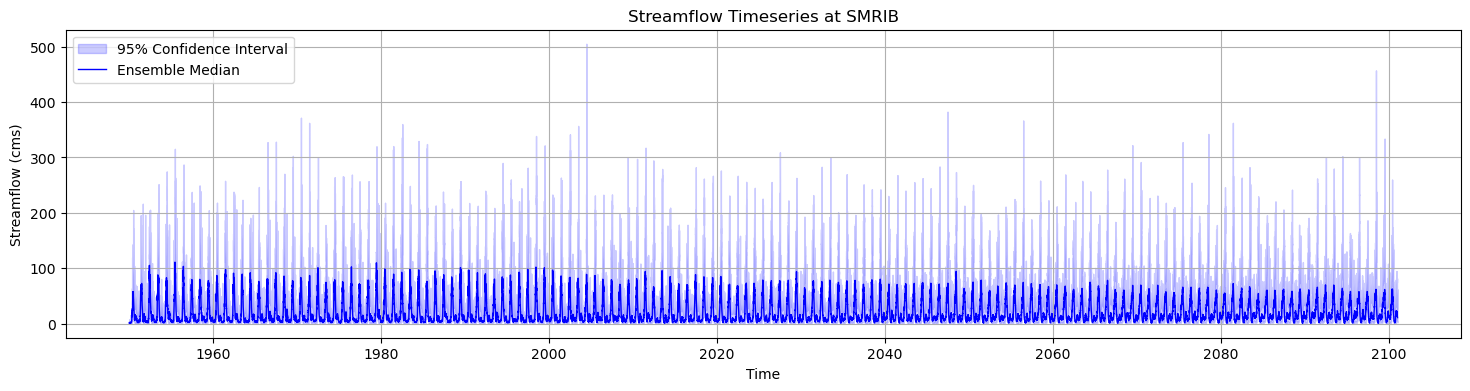

In [7]:
# Plot Milk River streamflow timeseries
plot_streamflow_time_series(stm_official_ensemble, 'SMRIB', output_directory, date_range=("1950-01-01", "2100-12-31"), log_y=False)